In [1]:
import numpy as np 
import scanpy as sc
import pandas as pd
from scipy.stats import entropy
import seaborn as sns
import matplotlib.pyplot as plt
sc.settings.set_figure_params(figsize=(3, 3), dpi=100)

/tmp/ipykernel_3006811/4278165821.py:7: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(figsize=(3, 3), dpi=100)


In [2]:
adata_1_processed = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")
adata_2_processed = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_2p5_processed = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")
adata_3_processed = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/processed/adata_loop3_500k_residual_processed.h5ad")

adata_3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k.h5ad")

In [3]:
adata_diversity = sc.concat([adata_1_processed,
                             adata_2_processed, 
                             adata_2p5_processed, 
                             adata_3_processed])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
adata_diversity = adata_diversity[~adata_diversity.obs.cell_type.isna()]

In [5]:
adata_diversity.obs["experiment_number"] = adata_diversity.obs["experiment_number"].astype(str)

/tmp/ipykernel_3006811/3603906777.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_diversity.obs["experiment_number"] = adata_diversity.obs["experiment_number"].astype(str)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Check if HID and 245 lie far from each other

In [6]:
protocol_cols = ['gm-csf_[ng_ml]', 
                 'tpo_[ng_ml]', 
                 'sr1_[nm]',
                 'um171_[nm]',
                 'um729_[µm]',
                 'scf_[ng_ml]',
                 'butyzamide_[nm]',
                 'retinoic_acid_[µm]',
                 'ldl_[ng_ml]',
                 'il3_[ng_ml]',
                 'o2_[%]',
                 'days_of_culture',
                 'il7_[ng_ml]',
                 'mcsf_[ng_ml]', 
                 'ly_cocktail_[ul/well]']

In [7]:
adata_l3_obs_proot = adata_3.obs.loc[:, protocol_cols].drop_duplicates()
adata_l3_obs = adata_3.obs.loc[adata_l3_obs_proot.index]

In [8]:
adata_prot = sc.AnnData(X=adata_l3_obs_proot.values, obs=adata_l3_obs)

In [9]:
sc.pp.log1p(adata_prot)
sc.tl.pca(adata_prot)

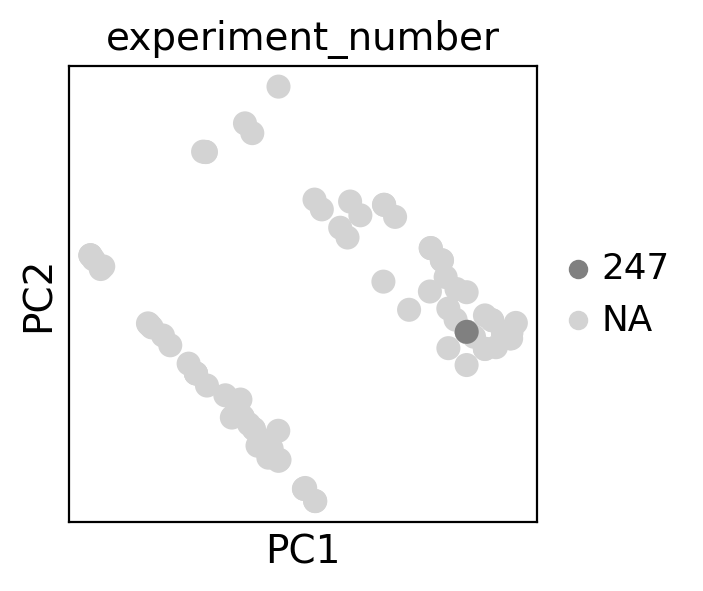

In [10]:
sc.pl.pca(adata_prot, color="experiment_number", s=300, groups=["247"])

# Classification results

In [11]:
adata_1_processed.obs.cell_type

223430-121       LMPP-CLP
64004-120        LMPP-CLP
78783-120     GMP_cycling
270319-118            NaN
438603-122    EosBasMast2
                 ...     
633-273        MgKEryPro1
8904-277        Early_GMP
2407-277              NaN
2148-277              MPP
3702-277              MPP
Name: cell_type, Length: 499956, dtype: category
Categories (25, object): ['HSCs' < 'earlyMPP' < 'MPP' < 'GMP-Neutro' ... 'CD16Mono' < 'CyclingPro1' < 'CyclingPro2' < '']

In [12]:
adata_1_processed[~adata_1_processed.obs.cell_type.isna()]

View of AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colo

In [13]:
adata_2p5_processed.obs.cell_type

122608-14     GMP-Neutro
47436-16      GMP-Neutro
214855-17     MgKEryPro1
137381-17    CyclingPro1
178809-12     MgKEryPro1
                ...     
89474-1       GMP-Neutro
116164-0     CyclingPro1
56229-2       MgKEryPro1
21772-1      CyclingPro1
124035-5     EosBasMast2
Name: cell_type, Length: 500000, dtype: category
Categories (24, object): ['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', ..., 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']

In [14]:
adata_3_processed.obs.cell_type

269705-9      GMP-Neutro
130226-6      MgKEryPro1
264293-6            HSCs
298341-8      MgKEryPro1
345799-8     EosBasMast1
                ...     
163915-40     GMP-Neutro
48501-38     EosBasMast1
2091-40         LMPP-CLP
115173-41            MPP
146665-41      Early_GMP
Name: cell_type, Length: 499996, dtype: category
Categories (24, object): ['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', ..., 'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2']

In [15]:
np.unique(adata_2_processed.obs.experiment_number)

array(['239', '240', '241', '242', '243', '244', '245', '246', '247'],
      dtype=object)

In [16]:
np.unique(adata_3_processed.obs.experiment_number)

array(['252', '253', '254', '255', '256', '257', '258'], dtype=object)

In [17]:
np.unique(adata_2p5_processed.obs.experiment_number)

array(['248', '249', '250', '251'], dtype=object)

In [18]:
np.unique(adata_1_processed.obs.experiment_number)

array([  40,   41,   42,   43,   53,   54,   55,   65,   66,   67,   77,
         78,   79,  105,  106,  107,  108,  109,  110,  111,  112,  113,
        114,  115,  116,  117,  118,  119,  120,  121,  122,  123,  125,
        126,  127,  128,  129,  130,  131,  133,  138,  139,  140,  141,
        142,  143,  144,  145,  146,  147,  157,  158,  159,  160,  161,
        162,  163,  164,  188,  189,  205,  206,  207,  208,  209,  210,
       1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099,
       1100, 1101, 1102, 1103, 1104, 1111, 1112, 1113, 1114, 1115, 1116,
       1117, 1118, 1119, 1120, 1138, 1139, 1140, 1141, 1142, 1143, 1144,
       1145, 1146, 1147, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176,
       1177, 1178, 1179, 1180, 1181, 1182, 1188, 1189, 2138, 2139, 4138,
       4139])

Concatenate the anndatas 

In [19]:
adata_1_processed.obs['il7_[ng_ml]'] = 0.0
adata_1_processed.obs['ly_cocktail_[ul/well]'] = 0.0
adata_1_processed.obs['mcsf_[ng_ml]'] = 0.0

adata_2_processed.obs['il7_[ng_ml]'] = 0.0
adata_2_processed.obs['ly_cocktail_[ul/well]'] = 0.0
adata_2_processed.obs['mcsf_[ng_ml]'] = 0.0

adata_2p5_processed.obs['il7_[ng_ml]'] = 0.0
adata_2p5_processed.obs['ly_cocktail_[ul/well]'] = 0.0
adata_2p5_processed.obs['mcsf_[ng_ml]'] = 0.0

In [20]:
adata_tot = sc.concat([adata_1_processed, adata_2_processed])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [21]:
adata_tot = sc.concat([adata_tot, adata_2p5_processed])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [22]:
adata_tot = sc.concat([adata_tot, adata_3_processed])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [23]:
adata_tot = adata_tot[~pd.isna(adata_tot.obs.cell_type)]
adata_tot.obs.experiment_number = adata_tot.obs.experiment_number.astype(str)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/pandas/core/generic.py:6351: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self[name] = value
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [24]:
recipe_entropies = {}

cell_type_list = np.unique(adata_tot.obs.cell_type)

In [25]:
recipe_entropies = {}
cell_types_generated = {}
hsc_prod = {}
mpp_prod = {}
hsc_counts_prod = {}
mpp_counts_prod = {}

cell_type_list = np.unique(adata_tot.obs.cell_type)

for exp_number in adata_tot.obs.experiment_number.unique():
    # Subset
    adata_exp = adata_tot[adata_tot.obs.experiment_number == exp_number]
    adata_exp_ct = adata_exp.obs.cell_type.value_counts()
    cell_types_generated[exp_number] = len(adata_exp_ct)

    for ct in cell_type_list:
        if ct not in adata_exp_ct.index:
            adata_exp_ct[ct] = 0

    # Reindex to guarantee consistent ordering across experiments
    adata_exp_ct = adata_exp_ct.reindex(cell_type_list)

    # Convert counts to proportions
    proportions = adata_exp_ct / adata_exp_ct.sum()

    # Compute Shannon entropy (base 2; use base=np.e for nats)
    recipe_entropies[exp_number] = entropy(proportions, base=np.e)
    hsc_prod[exp_number] = proportions["HSCs"]
    mpp_prod[exp_number] = proportions["MPP"]
    hsc_counts_prod[exp_number] = adata_exp_ct["HSCs"]
    mpp_counts_prod[exp_number] = adata_exp_ct["MPP"]

recipe_entropies

{'1113': np.float64(2.122130407433554),
 '1189': np.float64(2.228426465276437),
 '1188': np.float64(2.1698400979210817),
 '1111': np.float64(2.1057688118799063),
 '119': np.float64(1.8151757812988838),
 '120': np.float64(2.1166514968269476),
 '1112': np.float64(2.2291630425753945),
 '1119': np.float64(2.1612242863578497),
 '1120': np.float64(2.1913092713230604),
 '1117': np.float64(2.103115562353527),
 '208': np.float64(2.142559166463728),
 '1138': np.float64(1.975212143543525),
 '141': np.float64(1.9975743759673947),
 '140': np.float64(2.0443479252354364),
 '143': np.float64(2.149000442407171),
 '139': np.float64(2.1259185680757606),
 '161': np.float64(2.256478720482277),
 '113': np.float64(1.7572938432271332),
 '125': np.float64(2.061708066916185),
 '206': np.float64(2.1376321184656817),
 '144': np.float64(2.1666167286386915),
 '210': np.float64(1.2081373457340152),
 '142': np.float64(2.141741774599392),
 '1176': np.float64(2.2543135283623315),
 '145': np.float64(2.148129117378086),


In [26]:
recipe_entropies_series = pd.Series(recipe_entropies)

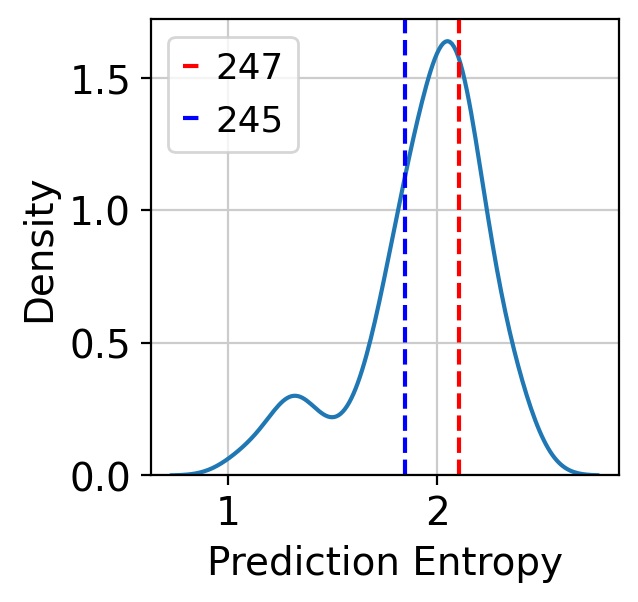

In [27]:
ax = sns.kdeplot(recipe_entropies_series)

# Add vertical lines for specific experiments
ax.axvline(recipe_entropies_series["247"], color="red", linestyle="--", label="247")
ax.axvline(recipe_entropies_series["245"], color="blue", linestyle="--", label="245")

ax.legend()
plt.xlabel("Prediction Entropy")
plt.show()

# Annotate PCA

In [28]:
adata_prot.obs.experiment_number = adata_prot.obs.experiment_number.astype(str)

In [29]:
# for i in recipe_entropies_series.index:
#     print(type(i))

# for i in adata_prot.index:
#     print(type(i))

In [30]:
adata_prot.obs["entropy"] = recipe_entropies_series.loc[adata_prot.obs.experiment_number].values

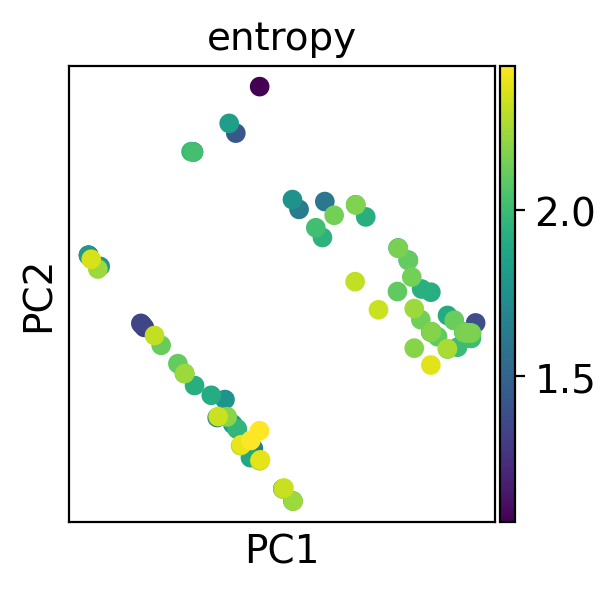

In [31]:
sc.pl.pca(adata_prot, color="entropy", s=200)

In [32]:
adata_tot[adata_tot.obs.experiment_number=="241"].obs.cell_type.value_counts()

cell_type
MgKEryPro1     10400
EosBasMast1     6641
GMP-Neutro      6419
late_MgkPro     5936
LMPP-CLP        5145
Early_GMP       4973
MPP             3549
EryPro          3391
GMP_cycling     2106
EosBasMast2     1948
pre_cDC1        1767
CD14Mono        1599
CD16Mono        1093
earlyMPP         244
HSCs             116
MLP               78
EosBasMast3       72
preProB           34
pre_cDC2          29
CyclingPro1        5
ProB               4
MPP_MgkEry         3
CyclingPro2        3
Name: count, dtype: int64

In [33]:
adata_tot[adata_tot.obs.experiment_number=="247"].obs.cell_type.value_counts() 

cell_type
EosBasMast1    13074
GMP-Neutro      9954
MgKEryPro1      8023
MPP             7672
EryPro          7433
Early_GMP       2230
LMPP-CLP        2220
GMP_cycling     1904
CD16Mono        1413
EosBasMast2      411
HSCs             287
MLP              248
earlyMPP         176
EosBasMast3      170
CD14Mono         122
MPP_MgkEry        87
pre_cDC2          61
preProB           25
MgKEryPro2        15
CyclingPro2       14
late_MgkPro        9
pre_cDC1           5
CyclingPro1        2
Name: count, dtype: int64

In [34]:
recipe_entropies_series

1113    2.122130
1189    2.228426
1188    2.169840
1111    2.105769
119     1.815176
          ...   
257     2.118543
252     2.001307
254     2.068485
255     2.055185
258     2.051365
Length: 142, dtype: float64

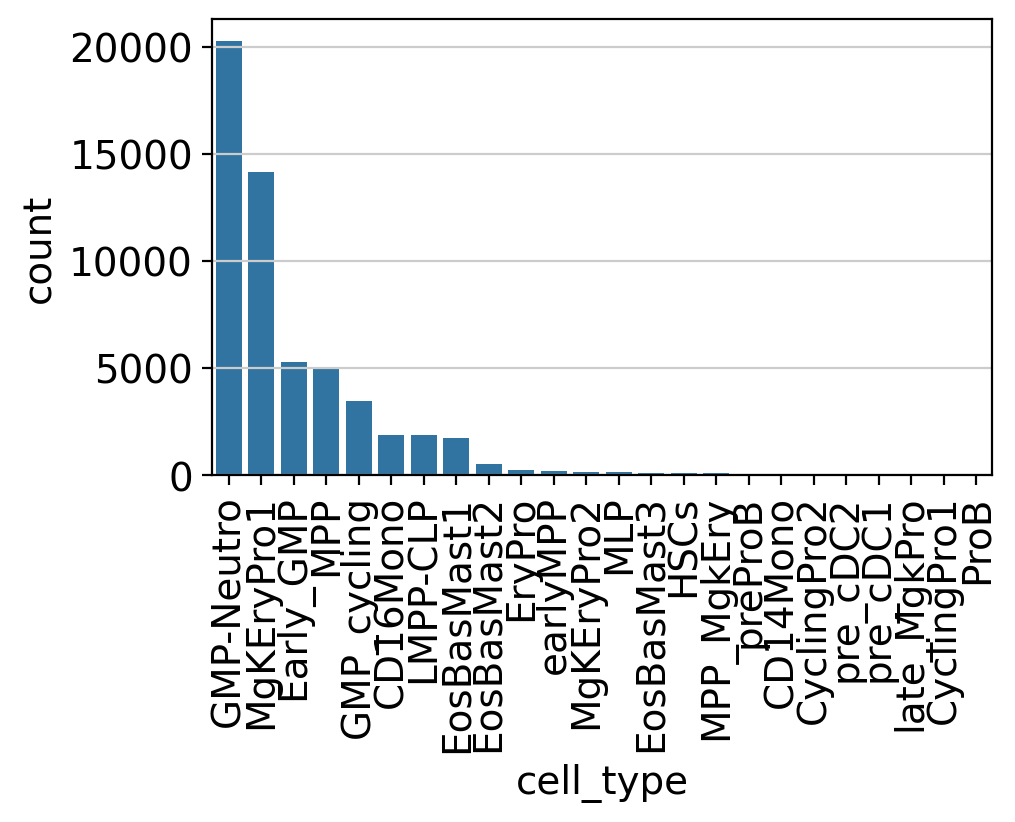

In [35]:
plt.figure(figsize=(5,3))
sns.barplot(adata_tot[adata_tot.obs.experiment_number=="245"].obs.cell_type.value_counts())
plt.xticks(rotation=90)
plt.show()

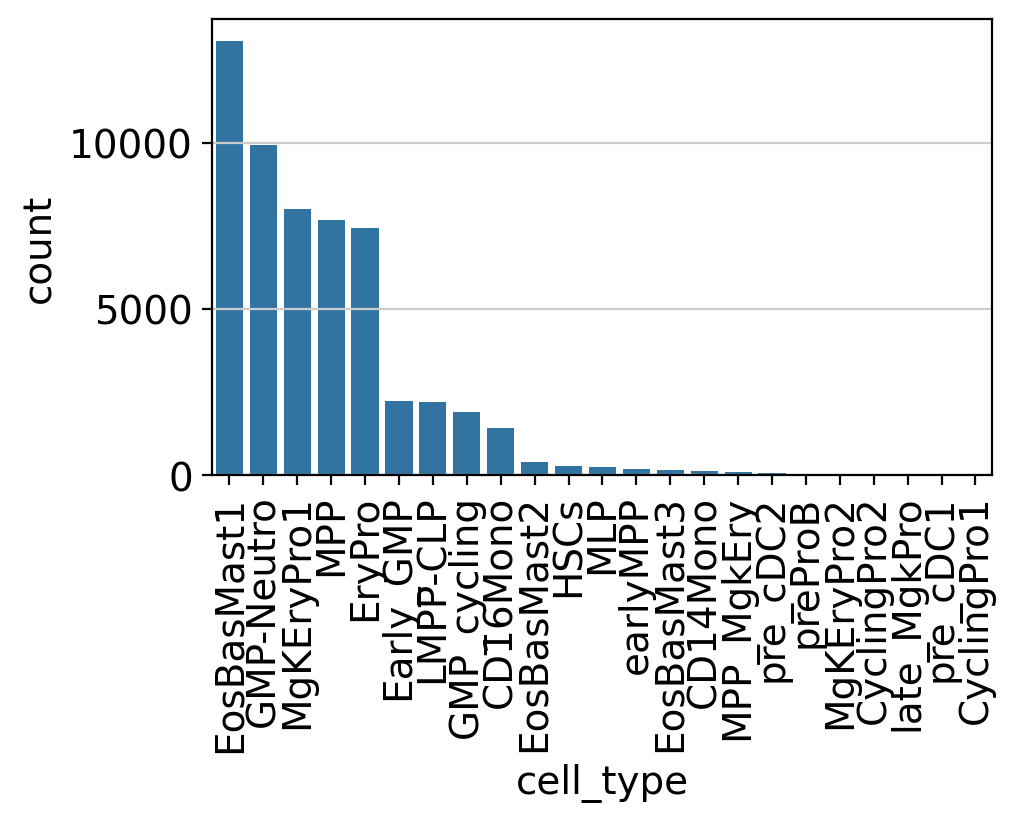

In [36]:
plt.figure(figsize=(5,3))
sns.barplot(adata_tot[adata_tot.obs.experiment_number=="247"].obs.cell_type.value_counts())
plt.xticks(rotation=90)
plt.show()

## Check HSCs

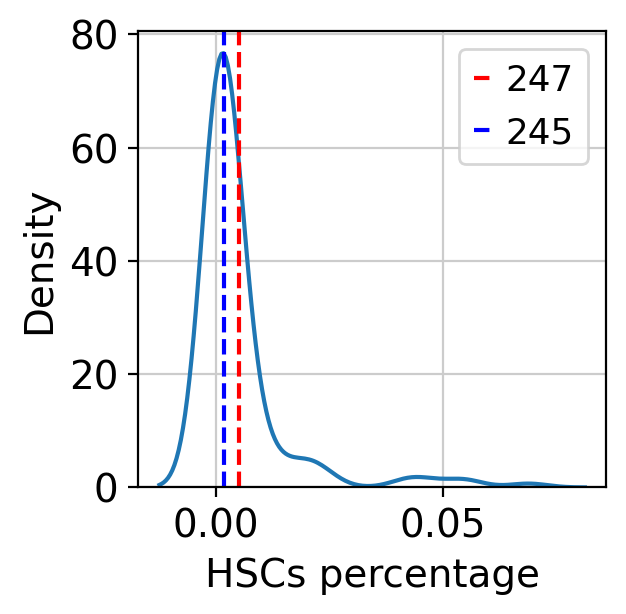

In [37]:
ax = sns.kdeplot(pd.Series(hsc_prod))

# Add vertical lines for specific experiments
ax.axvline(hsc_prod["247"], color="red", linestyle="--", label="247")
ax.axvline(hsc_prod["245"], color="blue", linestyle="--", label="245")

ax.legend()
plt.xlabel("HSCs percentage")
plt.show()

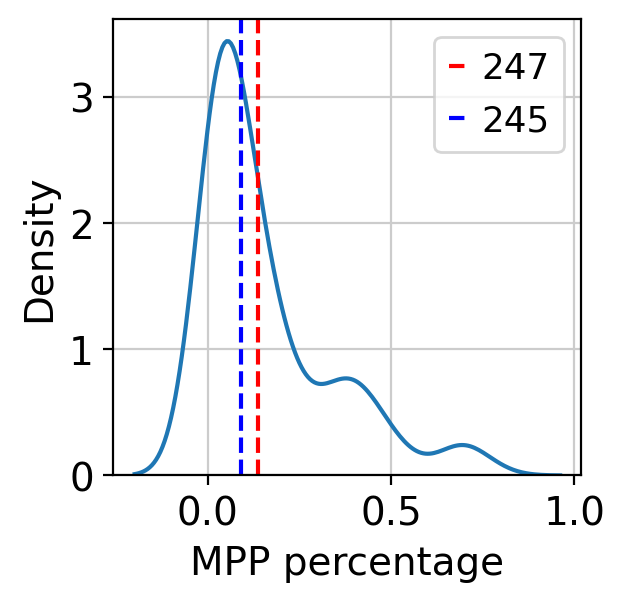

In [38]:
ax = sns.kdeplot(pd.Series(mpp_prod))

# Add vertical lines for specific experiments
ax.axvline(mpp_prod["247"], color="red", linestyle="--", label="247")
ax.axvline(mpp_prod["245"], color="blue", linestyle="--", label="245")

ax.legend()
plt.xlabel("MPP percentage")
plt.show()

## Plot tradeoffs

In [39]:
adata_prot.obs.experiment_number

223430-121    1113
120579-175    1189
34864-165     1188
215693-108    1111
113289-72      119
              ... 
202203-34      257
292145-4       252
427642-16      254
426931-18      255
157117-40      258
Name: experiment_number, Length: 123, dtype: object

In [40]:
adata_prot.obs["HSC_perc"] = pd.Series(hsc_prod)[adata_prot.obs.experiment_number.values].values
adata_prot.obs["MPP_perc"] = pd.Series(mpp_prod)[adata_prot.obs.experiment_number.values].values
adata_prot.obs["HSC_count"] = pd.Series(hsc_counts_prod)[adata_prot.obs.experiment_number.values].values
adata_prot.obs["MPP_count"] = pd.Series(mpp_counts_prod)[adata_prot.obs.experiment_number.values].values

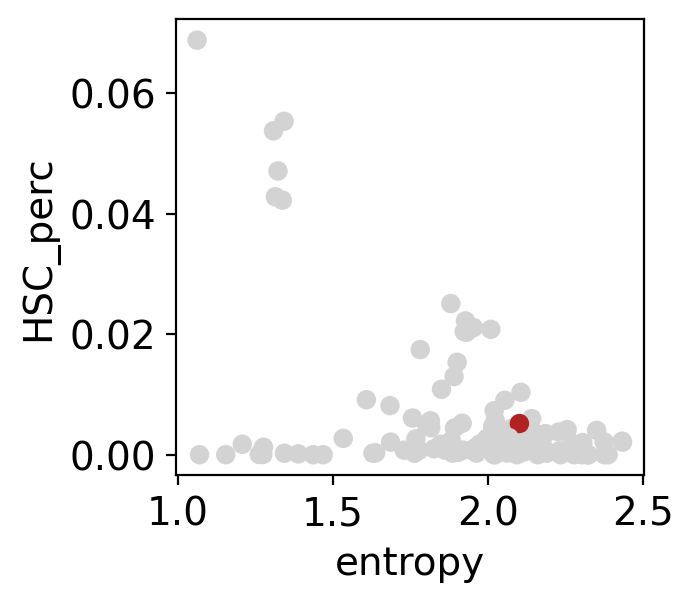

In [41]:
colors = adata_prot.obs['experiment_number'].map({
    "247": 'firebrick',
    # "245": 'blue',
    # "241": "green"
}).fillna('lightgray')

fig, ax = plt.subplots()
ax.scatter(adata_prot.obs['entropy'], adata_prot.obs['HSC_perc'], c=colors)
ax.set_xlabel('entropy')
ax.set_ylabel('HSC_perc')
plt.grid(None)

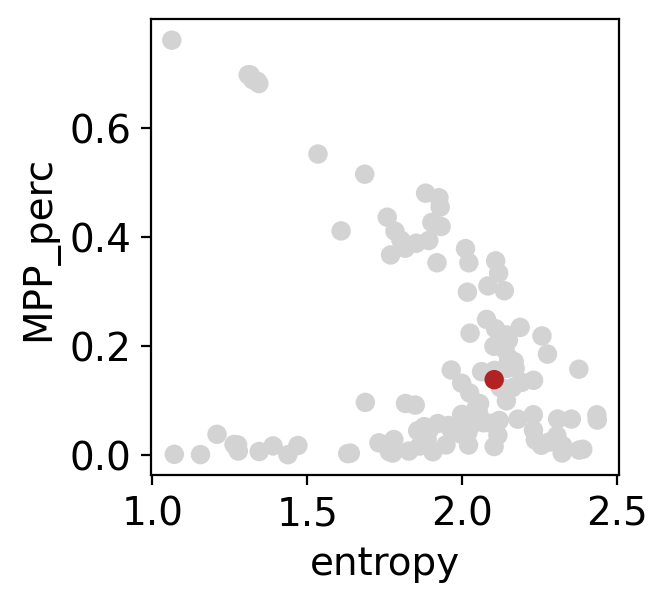

In [42]:
fig, ax = plt.subplots()
ax.scatter(adata_prot.obs['entropy'], adata_prot.obs['MPP_perc'], c=colors)
ax.set_xlabel('entropy')
ax.set_ylabel('MPP_perc')
plt.grid(None)

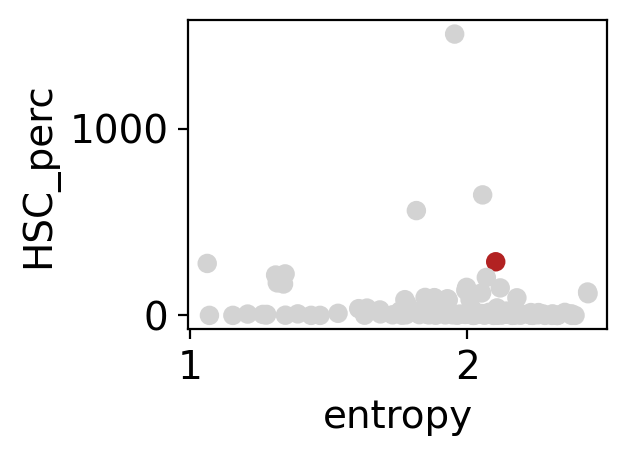

In [43]:
fig, ax = plt.subplots(figsize=(3.5,2.5))
ax.scatter(adata_prot.obs['entropy'], adata_prot.obs['HSC_count'], c=colors)
ax.set_xlabel('entropy')
ax.set_ylabel('HSC_perc')
plt.grid(None)
plt.tight_layout()
plt.savefig("hsc_counts_vs_entropy.svg")

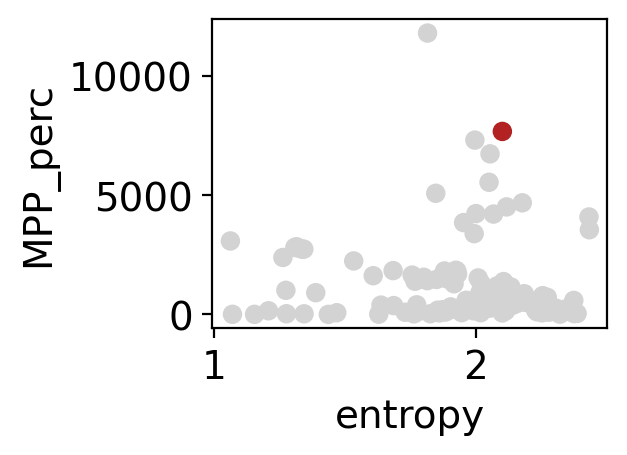

In [44]:
fig, ax = plt.subplots(figsize=(3.5,2.5))
ax.scatter(adata_prot.obs['entropy'], adata_prot.obs['MPP_count'], c=colors)
ax.set_xlabel('entropy')
ax.set_ylabel('MPP_perc')
plt.grid(None)
plt.tight_layout()
plt.savefig("mpp_counts_vs_entropy.svg")

## Difference from 245 and HID 

In [45]:
adata_prot_exp = adata_prot.copy()
adata_prot_exp.X = np.exp(adata_prot_exp.X)-1

In [46]:
adata_prot_exp.var["parameter_names"] = protocol_cols

In [47]:
adata_prot_exp = sc.concat([adata_prot_exp[:, :12],adata_prot_exp[:, 13:]], axis=1)
adata_prot_exp.obs = adata_prot.obs

In [48]:
# adata_prot_exp.X = (adata_prot_exp.X - adata_prot_exp.X.mean(0, keepdims=True)) / adata_prot_exp.X.std(0, keepdims=True)
# adata_prot_exp.X

In [49]:
X_hid = adata_prot_exp[adata_prot_exp.obs.experiment_number=="247"]

In [50]:
X_not_hid = adata_prot_exp[adata_prot_exp.obs.experiment_number!="247"]

In [51]:
dist_mat = ((X_hid.X[:,None] - X_not_hid.X)**2).mean(-1).squeeze()

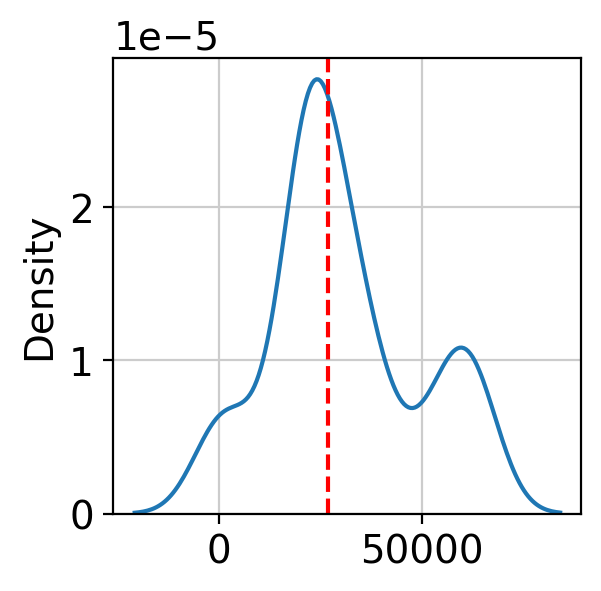

In [52]:
sns.kdeplot(dist_mat)
val_245 = dist_mat[X_not_hid.obs.experiment_number=="245"]
plt.axvline(x=val_245, color='red', linestyle='--')

In [53]:
adata_prot.obs["HSC_count"] = np.log1p(adata_prot.obs["HSC_count"])
adata_prot.obs["MPP_count"] = np.log1p(adata_prot.obs["MPP_count"])

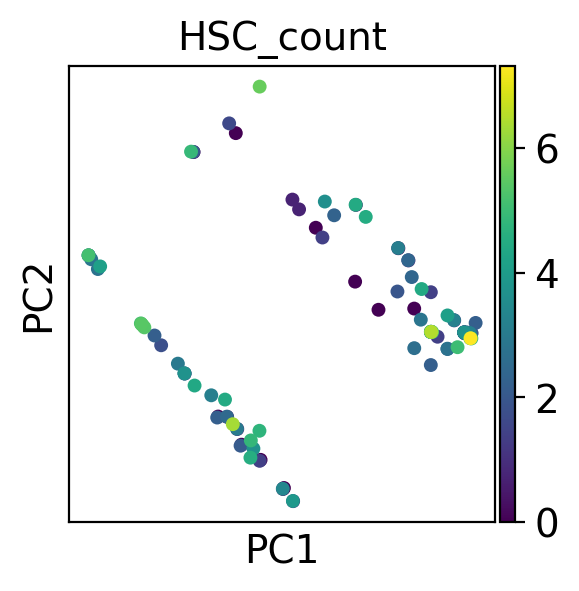

In [54]:
sc.pl.pca(adata_prot, color="HSC_count", s=100)

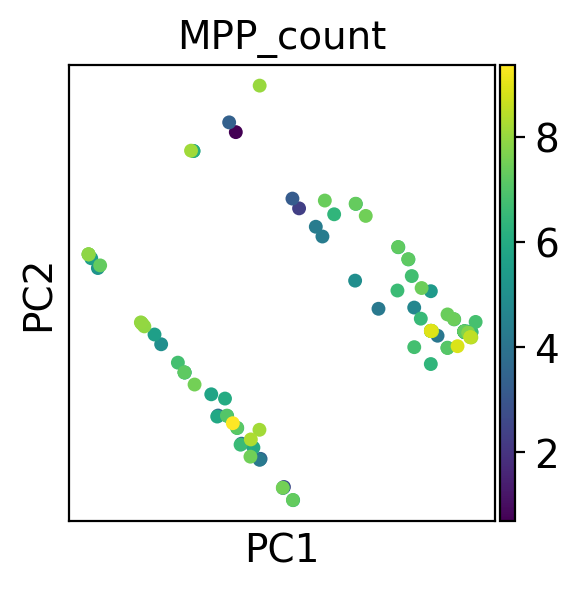

In [55]:
sc.pl.pca(adata_prot, color="MPP_count", s=100)

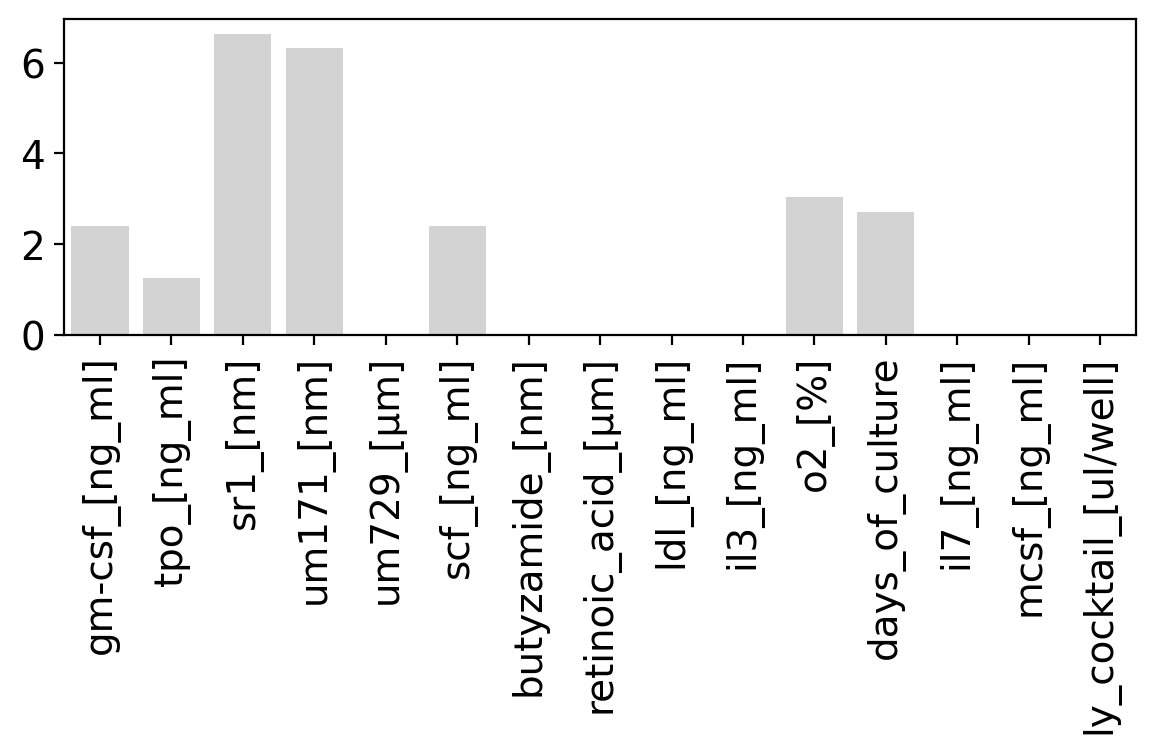

In [56]:
plt.figure(figsize=(6,4))
sns.barplot(np.log1p(adata_prot.obs[adata_prot.obs["experiment_number"]=="247"][protocol_cols].astype(float)),
           color="lightgray")
plt.xticks(rotation=90)
plt.grid(False)
plt.tight_layout()
plt.savefig("hid_protocol.svg")
plt.show()

## Compare 247 and 245

In [89]:
barplot_df = {"protocol": [], 
              "proportion": [],
              "cell_type": []}

In [90]:
all_ct = np.unique(adata_diversity.obs.cell_type)

for exp in ["245", "247"]:
    adata_diversity_exp = adata_diversity[adata_diversity.obs.experiment_number==exp] 
    adata_diversity_exp_ct = adata_diversity_exp.obs["cell_type"].value_counts() / adata_diversity_exp.shape[0]
    for ct in all_ct:
        barplot_df["cell_type"].append(ct)
        if ct not in adata_diversity_exp_ct.index:
            barplot_df["proportion"].append(0)
        else:
            barplot_df["proportion"].append(adata_diversity_exp_ct[ct])
        
        barplot_df["protocol"].append(exp)

In [91]:
barplot_df = pd.DataFrame(barplot_df)

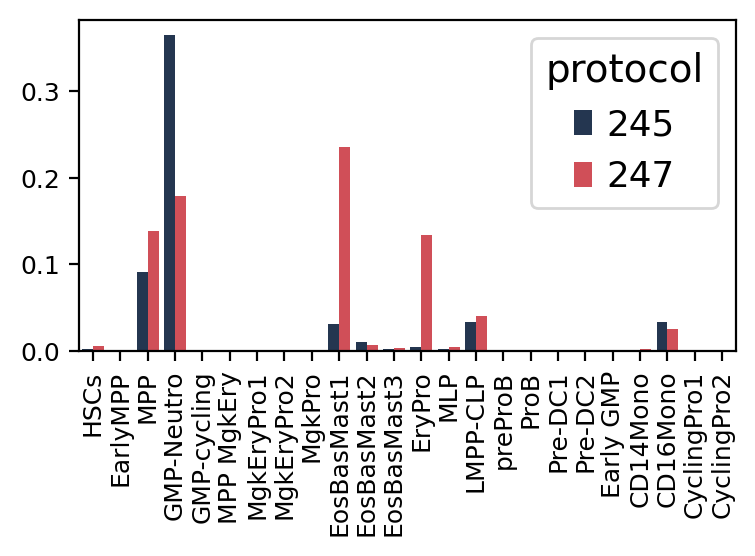

In [117]:
order = ["HSCs", "EarlyMPP", "MPP", "GMP-Neutro", "GMP-cycling", "MPP MgkEry", 
         "MgkEryPro1", "MgkEryPro2", "MgkPro", "EosBasMast1", "EosBasMast2", 
         "EosBasMast3", "EryPro", "MLP", "LMPP-CLP", "preProB", "ProB", 
         "Pre-DC1", "Pre-DC2", "Early GMP", "CD14Mono", "CD16Mono", 
         "CyclingPro1", "CyclingPro2"]

plt.figure(figsize=(4,3))
sns.barplot(barplot_df, x="cell_type", y="proportion", hue="protocol", 
            order=order, palette={"245": "#1d3557", "247": "#e63946"})
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.grid(False)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("prop_differences.svg")
plt.show()